<a href="https://colab.research.google.com/github/sabali-sez/predicting-mobile-money-transaction-fraud./blob/main/complete%20project%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from sklearn import preprocessing
from sklearn import utils

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve,auc
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import PolynomialFeatures

data = pd.read_csv("/content/ResearchDataSet.csv")

data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [37]:
data=data.drop(["nameOrig","nameDest","step","isFlaggedFraud" ,"type"],axis=1)

In [38]:
data.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,9839.64,170136.0,160296.36,0.0,0.0,0
1,1864.28,21249.0,19384.72,0.0,0.0,0
2,181.00,181.0,0.00,0.0,0.0,1
3,181.00,181.0,0.00,21182.0,0.0,1
4,11668.14,41554.0,29885.86,0.0,0.0,0


In [39]:
data = data.replace([np.inf, -np.inf], np.nan).fillna(1)

In [40]:
X = data.iloc[:,0:-1].values
y = data.iloc[:,-1].values

In [41]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2)

In [42]:
print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(838860, 5)
(209715, 5)
(838860,)
(209715,)


In [43]:
min_max_scaler=MinMaxScaler()
Xtrain=min_max_scaler.fit_transform(Xtrain)
Xtest=min_max_scaler.fit_transform(Xtest)


IMPLEMENTING RANDOM FOREST CLASSIFIER

In [44]:
rf=RandomForestClassifier(max_features=0.2)
rf.fit(Xtrain,ytrain)

y_pred =rf.predict(Xtest)
pred_prob = rf.predict_proba(Xtest)


CHECKING FOR ACCURACY SCORE

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cmx1=confusion_matrix(ytest,y_pred)
print(cmx1)
print(accuracy_score(ytest,y_pred))

[[209453      9]
 [   133    120]]
0.9993228905896097


CLASSIFICATION REPORT FOR RANDOM FOREST

In [46]:
from sklearn.metrics import classification_report
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209462
           1       0.93      0.47      0.63       253

    accuracy                           1.00    209715
   macro avg       0.96      0.74      0.81    209715
weighted avg       1.00      1.00      1.00    209715



IMPLEMENTING LOGISTIC REGRESSION  CLASSIFIER

In [47]:
#clf = LogisticRegression(random_state=0).fit(Xtrain,ytrain)
#clf.predict(Xtrain,ytrain)
lrc = LogisticRegression(random_state=4)
lrc.fit(Xtrain,ytrain)

y_pred =rf.predict(Xtest)
pred_prob = rf.predict_proba(Xtest)

In [48]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cmx2=confusion_matrix(ytest,y_pred)
print(cmx2)
print(accuracy_score(ytest,y_pred))

[[209453      9]
 [   133    120]]
0.9993228905896097


CLASSIFICATION REPORT FOR LOGISTIC REGRESSION

In [49]:
from sklearn.metrics import classification_report
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209462
           1       0.93      0.47      0.63       253

    accuracy                           1.00    209715
   macro avg       0.96      0.74      0.81    209715
weighted avg       1.00      1.00      1.00    209715



IMPLEMENTING DECISION TREE CLASSFIER

In [50]:
dtc=DecisionTreeClassifier()
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [51]:
dtc.fit(Xtrain,ytrain)

DecisionTreeClassifier()

In [52]:
y_pred =dtc.predict(Xtest)
pred_prob = dtc.predict_proba(Xtest)

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cmx3=confusion_matrix(ytest,y_pred)
print(cmx3)
print(accuracy_score(ytest,y_pred))


[[209351    111]
 [    73    180]]
0.9991226187921703


CLASSIFICATION REPORT FOR DECISION TREE MODEL

In [53]:
from sklearn.metrics import classification_report
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209462
           1       0.62      0.71      0.66       253

    accuracy                           1.00    209715
   macro avg       0.81      0.86      0.83    209715
weighted avg       1.00      1.00      1.00    209715



MODEL EVALUATION WITH A AROC AU

In [54]:
def plot_roc(xtest,ytest,models):

    #models object should be a dictionary comprising of name of model and the model object
    for name,model in models.items():

        if hasattr(model,'decision_function'):
            probs=model.decision_function(xtest)
        elif hasattr(model,'predict_proba'):
            probs=model.predict_proba(xtest) [:,1]
        fpr,tpr,threshold=roc_curve(ytest,probs)
        roc_auc=auc(fpr,tpr)
        print('ROC AUC=%0.2f'%roc_auc)
        plt.plot(fpr,tpr,label='%s (AUC=%0.2f)'%(name,roc_auc))

    plt.legend(loc='lower right')
    plt.plot([0,1],[0,1],'b--')
    plt.xlim([0,1])
    plt.ylim([0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

ROC AUC=0.98
ROC AUC=0.82
ROC AUC=0.76


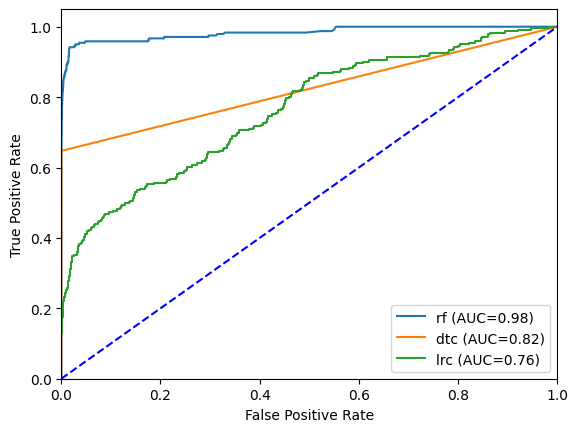

In [33]:
models={'rf':rf,'dtc':dtc,'lrc':lrc}
plot_roc(Xtest,ytest,models)